In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir('/home/sebastiaan/phd/repositories/immune_response_detection/')

from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import mannwhitneyu, ttest_ind
from parse_albert_seqs import parse_file
from clustcrdist.constants.parsing import parse_yfv_repertoires, parse_britanova_repertoires, IMGT
from clustcrdist.indexing import FlatIndex
from clustcrdist.encoding import TCRDistEncoder
from clustcrdist.neighbors import neighbor_analysis, tcr_dict_to_df, index_neighbors, SneTcrResult
from clustcrdist.repertoire import Repertoire
from clustcrdist.background import BackgroundModel
from clustcrdist.constants.preprocessing import adaptive_to_imgt_mouse
from clustcrdist.constants.parsing import _is_cdr3
from clustcrdist.viz import simple_beeswarm

# Setting up the plot styles
plt.style.use(['seaborn-white', 'seaborn-paper'])
plt.rc('font', family='serif')
sns.set_palette('Set1')
sns.set_context('paper', font_scale=1.3)    # single-column figure

/tmp/ipykernel_1850286/982750875.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['seaborn-white', 'seaborn-paper'])
/tmp/ipykernel_1850286/982750875.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(['seaborn-white', 'seaborn-paper'])


## **Mouse data: naive vs memory**

In [180]:
# Files
mouse_data = "../sne_manuscript/data/albert/2102-Naive/"
files = [f for f in os.listdir(mouse_data) if "donor" in f]
naive_sizes = {}

for i in files:
    df = parse_file(f"{mouse_data}{i}")
    df = pd.DataFrame(df)
    df.columns = ['v_adaptive','v_call','j_call','junction_aa','junction']
    naive_sizes[i] = df.shape[0]

mouse_data = "../sne_manuscript/data/albert/2102-Memory/"
files = [f for f in os.listdir(mouse_data) if "donor" in f]

mem_sizes = {}
for i in files:
    df = parse_file(f"{mouse_data}{i}")
    df = pd.DataFrame(df)
    df.columns = ['v_adaptive','v_call','j_call','junction_aa','junction']
    mem_sizes[i] = df.shape[0]

In [169]:
for key in mem_sizes.keys():
    print(key)

    sne = pd.read_table(f'../sne_manuscript/analysis/albert/{key}')
    sne['eval'] = sne.pval * mem_sizes[key]

    n = sne[sne['eval']<0.05].shape[0]
    mem_sizes[key] = (mem_sizes[key], n)

for key in naive_sizes.keys():
    print(key)

    sne = pd.read_table(f'../sne_manuscript/analysis/albert/{key}')
    sne['eval'] = sne.pval * naive_sizes[key]

    n = sne[sne['eval']<0.05].shape[0]
    naive_sizes[key] = (naive_sizes[key], n)

2102-T2-donorM1.tsv
2102-T2-donorM3.tsv
2102-T2-donorM2.tsv
2102-T2-donorM4.tsv
2102-T2-donorN2.tsv
2102-T2-donorN6.tsv
2102-T2-donorN3.tsv
2102-T2-donorN4.tsv
2102-T2-donorN5.tsv
2102-T2-donorN1.tsv


Mann-Whitney U test result: p-value = 0.008677529337777653
MannwhitneyuResult(statistic=0.0, pvalue=0.008677529337777653)


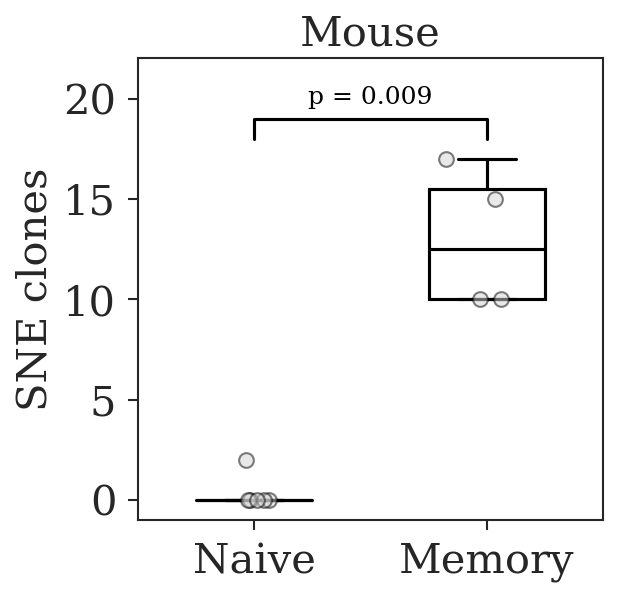

In [174]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

naive_sne = [i[1] for i in naive_sizes.values()]
memory_sne = [i[1] for i in mem_sizes.values()]

# Define the properties for the error bars
capprops = {"color": "black", "linewidth": 1.5}
whiskerprops = {"color": "black", "linewidth": 1.5}

# Boxplot properties
bprop1 = {"facecolor":"white","linewidth":1.5}
bprop2 = {"facecolor":"white","linewidth":1.5}
medprops = {"color":"black","linewidth":1.5}

# Create the first boxplot for naive_sne with error bar properties
bplot1 = ax.boxplot(naive_sne, 
                    showfliers=False, 
                    positions=[0], 
                    widths=0.5, 
                    zorder=0, 
                    patch_artist=True, 
                    vert=True, 
                    boxprops=bprop1, 
                    medianprops=medprops, 
                    capprops=capprops, 
                    whiskerprops=whiskerprops)

# Create the second boxplot for memory_sne with error bar properties
bplot2 = ax.boxplot(memory_sne, 
                    showfliers=False, 
                    positions=[1], 
                    widths=0.5, 
                    zorder=0, 
                    patch_artist=True, 
                    vert=True, 
                    boxprops=bprop2, 
                    medianprops=medprops, 
                    capprops=capprops, 
                    whiskerprops=whiskerprops)

ax.scatter(
    x = simple_beeswarm(naive_sne, width=.1),
    y = naive_sne,
    edgecolor='black',
    linewidth=1,
    color='lightgrey',
    s=50,
    alpha=.5
)

ax.scatter(
    x = simple_beeswarm(memory_sne, width=.1) + 1,
    y = memory_sne,
    edgecolor='black',
    linewidth=1,
    color='lightgrey',
    s=50,
    alpha=.5
)

ax.set_xticklabels(['Naive', 'Memory'], fontsize=20)
yticks = [0,5,10,15,20]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize=20)
ax.set_ylim(-1,22)

# Mann-Whitney U test
stat, p_value = mannwhitneyu(naive_sne, memory_sne)
print(f"Mann-Whitney U test result: p-value = {p_value}")

# Add a line with brackets for annotation (p-value)
x1, x2 = 0, 1   # Positions for the two boxplots
y, h, col = max(memory_sne) + 1, 1, 'k'  # Starting y position for the line, height, and color

ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
ax.text((x1 + x2) * .5, y + h+.5, f'p = {p_value:.3f}', ha='center', va='bottom', color='black', fontsize=12)

ax.set_title('Mouse', fontsize=20)
ax.set_ylabel('SNE clones', fontsize=20)

print(mannwhitneyu(naive_sne, memory_sne))

fig.savefig('../sne_manuscript/manuscript_figures/fig2a.png', dpi=500, bbox_inches='tight')

## **Human data: naive vs central and effector memory** 

In [39]:
naive = []

naivedir = os.listdir('/home/sebastiaan/phd/data/ms_public/amoriello2020/enriched/naive/')

for i in naivedir:

    df = pd.read_table(f'/home/sebastiaan/phd/data/ms_public/amoriello2020/parsed/{i.split(".")[0]}.txt')
    sne = pd.read_table(f'/home/sebastiaan/phd/data/ms_public/amoriello2020/enriched/naive/{i.split(".")[0]}.txt.gz')

    formatter = Repertoire(df)
    df = formatter.filter_and_format_single()
    df = df.reset_index(drop=True)

    sne['evalue'] = sne.pval * df.shape[0]
    sneres = SneTcrResult(sne, 'B')

    sign = sneres.data[sneres.data['evalue']<0.05]

    if sign.shape[0] == 0:
        naive.append((i.split(".")[0], df.shape[0], 0, 0))
    
    else:
        sneres.get_clusters(r=12.5)
        nsne = sneres.data[sneres.data['evalue']<0.05].shape[0]
        nclus = sneres.data.cluster.nunique()
        naive.append((i.split(".")[0], df.shape[0], nsne, nclus))

emem = [] 

ememdir = os.listdir('/home/sebastiaan/phd/data/ms_public/amoriello2020/enriched/emem/')

for i in ememdir:

    df = pd.read_table(f'/home/sebastiaan/phd/data/ms_public/amoriello2020/parsed/{i.split(".")[0]}.txt')
    sne = pd.read_table(f'/home/sebastiaan/phd/data/ms_public/amoriello2020/enriched/emem/{i.split(".")[0]}.txt.gz')

    formatter = Repertoire(df)
    df = formatter.filter_and_format_single()
    df = df.reset_index(drop=True)

    sne['evalue'] = sne.pval * df.shape[0]
    sneres = SneTcrResult(sne, 'B')

    sign = sneres.data[sneres.data['evalue']<0.05]

    if sign.shape[0] == 0:
        emem.append((i.split(".")[0], df.shape[0], 0, 0))
    
    else:
        sneres.get_clusters(r=12.5)
        nsne = sneres.data[sneres.data['evalue']<0.05].shape[0]
        nclus = sneres.data.cluster.nunique()
        emem.append((i.split(".")[0], df.shape[0], nsne, nclus))

cmem = []

cmemdir = os.listdir('/home/sebastiaan/phd/data/ms_public/amoriello2020/enriched/cmem/')

for i in cmemdir:

    df = pd.read_table(f'/home/sebastiaan/phd/data/ms_public/amoriello2020/parsed/{i.split(".")[0]}.txt')
    sne = pd.read_table(f'/home/sebastiaan/phd/data/ms_public/amoriello2020/enriched/cmem/{i.split(".")[0]}.txt.gz')

    formatter = Repertoire(df)
    df = formatter.filter_and_format_single()
    df = df.reset_index(drop=True)

    sne['evalue'] = sne.pval * df.shape[0]
    sneres = SneTcrResult(sne, 'B')

    sign = sneres.data[sneres.data['evalue']<0.05]

    if sign.shape[0] == 0:
        emem.append((i.split(".")[0], df.shape[0], 0, 0))
    
    else:
        sneres.get_clusters(r=12.5)
        nsne = sneres.data[sneres.data['evalue']<0.05].shape[0]
        nclus = sneres.data.cluster.nunique()
        cmem.append((i.split(".")[0], df.shape[0], nsne, nclus))

Remove ambiguous CDR3 amino acid sequences
Parsing V/J genes
Removed 0 with non-functional or misannotated V genes.
Parsing CDR3 nucleotide sequence
dropped 0 TCRs with ambiguous junctions
Autodetected V gene column: v_call
Autodetected CDR3AA column: junction_aa
Autodetected V gene column: v_call
Autodetected CDR3AA column: junction_aa
Encoding TCRs took 0.01s
Building the index took 0.00s
Searching index within radius 12.5 took 0.00s
Building the sparse matrix took 0.00s
Total time to compute distance matrix: 0.13s
Remove ambiguous CDR3 amino acid sequences
Parsing V/J genes
Removed 0 with non-functional or misannotated V genes.
Parsing CDR3 nucleotide sequence
dropped 0 TCRs with ambiguous junctions
Autodetected V gene column: v_call
Autodetected CDR3AA column: junction_aa
Autodetected V gene column: v_call
Autodetected CDR3AA column: junction_aa
Encoding TCRs took 0.01s
Building the index took 0.00s
Searching index within radius 12.5 took 0.03s
Building the sparse matrix took 0.00s

In [181]:


# fig, ax = plt.subplots(dpi=150, figsize=(4,4))

# bplot1 = ax.boxplot(naive_res['sne'] / naive_res['size'], 
#                     showfliers=False, 
#                     positions=[0], 
#                     widths=0.5, 
#                     zorder=0, 
#                     patch_artist=True, 
#                     vert=True, 
#                     boxprops=bprop1, 
#                     medianprops=medprops, 
#                     capprops=capprops, 
#                     whiskerprops=whiskerprops)

# bplot2 = ax.boxplot(emem_res['sne'] / emem_res['size'], 
#                     showfliers=False, 
#                     positions=[1], 
#                     widths=0.5, 
#                     zorder=0, 
#                     patch_artist=True, 
#                     vert=True, 
#                     boxprops=bprop2, 
#                     medianprops=medprops, 
#                     capprops=capprops, 
#                     whiskerprops=whiskerprops)

# bplot3 = ax.boxplot(cmem_res['sne'] / cmem_res['size'], 
#                     showfliers=False, 
#                     positions=[2], 
#                     widths=0.5, 
#                     zorder=0, 
#                     patch_artist=True, 
#                     vert=True, 
#                     boxprops=bprop3, 
#                     medianprops=medprops, 
#                     capprops=capprops, 
#                     whiskerprops=whiskerprops)

# naive_sne = naive_res['sne'] / naive_res['size']
# ax.scatter(
#     x = simple_beeswarm(naive_sne, width=.1) + 0,
#     y = naive_sne,
#     edgecolor='black',
#     linewidth=1,
#     color='#FA8909',
#     s=100,
#     alpha=.5
# )

# emem_sne = emem_res['sne'] / emem_res['size']
# ax.scatter(
#     x = simple_beeswarm(emem_sne, width=.1) + 1,
#     y = emem_sne,
#     edgecolor='black',
#     linewidth=1,
#     color='#5dade2',
#     s=100,
#     alpha=.5
# )

# cmem_sne = cmem_res['sne'] / cmem_res['size']
# ax.scatter(
#     x = simple_beeswarm(cmem_sne, width=.1) + 2,
#     y = cmem_sne,
#     edgecolor='black',
#     linewidth=1,
#     color='#2471a3',
#     s=100,
#     alpha=.5
# )

In [182]:
# metadata
meta = pd.read_table('/home/sebastiaan/phd/data/ms_public/amoriello2020/meta.txt')

# Collect the results
cols = ['sample_id', 'size', 'sne', 'clusters']
naive_res = pd.DataFrame(naive)
naive_res.columns = cols
emem_res = pd.DataFrame(emem)
emem_res.columns = cols
cmem_res = pd.DataFrame(cmem)
cmem_res.columns = cols
naive_res['fraction'] = 'naive'
emem_res['fraction'] = 'emem'
cmem_res['fraction'] = 'cmem'

# Merge the results
all_res = pd.concat([naive_res, emem_res, cmem_res])
all_res['sample_id'] = all_res.sample_id.astype(str)
meta = pd.read_table('/home/sebastiaan/phd/data/ms_public/amoriello2020/meta.txt')
meta['sample_id'] = meta.sample_id.astype(str)

all_res = all_res.merge(meta, left_on='sample_id', right_on='sample_id')
all_res = all_res[all_res.timepoint == 't0']

all_res['sne_fraction'] = all_res['sne'] / all_res['size']

cat1 = all_res[all_res.fraction == 'naive']
cat1cd4 = cat1[cat1.tcell_subset == 'CD4 naive']

cat2 = all_res[all_res.fraction == 'emem']
cat2cd4 = cat2[cat2.tcell_subset == 'CD4 EM']

cat3 = all_res[all_res.fraction == 'cmem']
cat3cd4 = cat3[cat3.tcell_subset == 'CD4 CM']


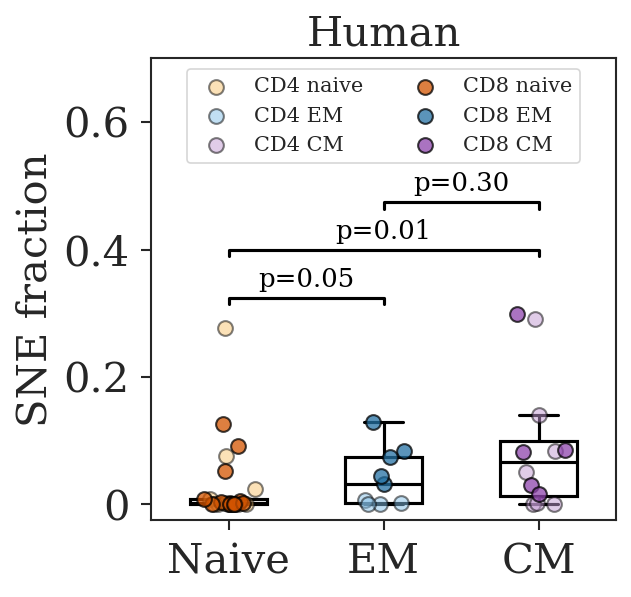

In [179]:
# Prepare boxplot aesthetics
# Define the properties for the error bars
capprops = {"color": "black", "linewidth": 1.5}
whiskerprops = {"color": "black", "linewidth": 1.5}

# Boxplot properties
bprop1 = {"facecolor":"white","linewidth":1.5}
bprop2 = {"facecolor":"white","linewidth":1.5}
bprop3 = {"facecolor":"white","linewidth":1.5}
medprops = {"color":"black","linewidth":1.5}

# Prepare plotting data
y1 = cat1cd4.sne_fraction
x1 = simple_beeswarm(y1, width=.1)

y2 = cat2cd4.sne_fraction
x2 = simple_beeswarm(y2, width=.1)

y3 = cat3cd4.sne_fraction
x3 = simple_beeswarm(y3, width=.1)

# Plotting
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

ax.scatter(
    x=x1, y=y1,
    edgecolor='black',linewidth=1,color='#f8c471',s=50,alpha=.5,
    label='CD4 naive'
)

ax.scatter(
    x=x2+1, y=y2,
    edgecolor='black',linewidth=1,color='#85c1e9',s=50,alpha=.5,
    label='CD4 EM'
)

ax.scatter(
    x=x3+2, y=y3,
    edgecolor='black',linewidth=1,color='#c39bd3',s=50,alpha=.5,
    label='CD4 CM'
)

cat1cd8 = cat1[cat1.tcell_subset == 'CD8 naive']
cat2cd8 = cat2[cat2.tcell_subset == 'CD8 EM']
cat3cd8 = cat3[cat3.tcell_subset == 'CD8 CM']

y1 = cat1cd8.sne_fraction
x1 = simple_beeswarm(y1, width=.1)

y2 = cat2cd8.sne_fraction
x2 = simple_beeswarm(y2, width=.1)

y3 = cat3cd8.sne_fraction
x3 = simple_beeswarm(y3, width=.1)

ax.scatter(
    x=x1, y=y1,
    edgecolor='black',linewidth=1,color='#d35400',s=50,alpha=.75,
    label='CD8 naive'
)

ax.scatter(
    x=x2+1, y=y2,
    edgecolor='black',linewidth=1,color='#2471a3',s=50,alpha=.75,
    label='CD8 EM'
)

ax.scatter(
    x=x3+2, y=y3,
    edgecolor='black',linewidth=1,color='#8e44ad',s=50,alpha=.75,
    label='CD8 CM'
)

bplot1 = ax.boxplot(cat1.sne_fraction, 
                    showfliers=False, 
                    positions=[0], 
                    widths=0.5, 
                    zorder=0, 
                    patch_artist=True, 
                    vert=True, 
                    boxprops=bprop1, 
                    medianprops=medprops, 
                    capprops=capprops, 
                    whiskerprops=whiskerprops)

bplot2 = ax.boxplot(cat2.sne_fraction, 
                    showfliers=False, 
                    positions=[1], 
                    widths=0.5, 
                    zorder=0, 
                    patch_artist=True, 
                    vert=True, 
                    boxprops=bprop2, 
                    medianprops=medprops, 
                    capprops=capprops, 
                    whiskerprops=whiskerprops)

bplot3 = ax.boxplot(cat3.sne_fraction, 
                    showfliers=False, 
                    positions=[2], 
                    widths=0.5, 
                    zorder=0, 
                    patch_artist=True, 
                    vert=True, 
                    boxprops=bprop3, 
                    medianprops=medprops, 
                    capprops=capprops, 
                    whiskerprops=whiskerprops)

from scipy.stats import mannwhitneyu

# Calculate p-values for the Mann-Whitney U test
p_value_naive_em = mannwhitneyu(cat1.sne_fraction, cat2.sne_fraction, alternative='less').pvalue
p_value_naive_cm = mannwhitneyu(cat1.sne_fraction, cat3.sne_fraction, alternative='less').pvalue
p_value_em_cm = mannwhitneyu(cat2.sne_fraction, cat3.sne_fraction, alternative='two-sided').pvalue

# Plot brackets with p-values
def add_p_value_annotation(ax, x1, x2, y, text):
    ax.plot([x1, x1, x2, x2], [y, y+0.01, y+0.01, y], lw=1.5, color='k')
    ax.text((x1+x2)*.5, y+0.02, text, ha='center', va='bottom', color='k')

# Set the position for annotations
y_max = max(cat1.sne_fraction.max(), cat2.sne_fraction.max(), cat3.sne_fraction.max()) * 1.05

# Add annotations
add_p_value_annotation(ax, 0, 1, y_max, f"p={p_value_naive_em:.2f}")
add_p_value_annotation(ax, 0, 2, y_max + 0.075, f"p={p_value_naive_cm:.2f}")
add_p_value_annotation(ax, 1, 2, y_max + 0.15, f"p={p_value_em_cm:.2f}")

ax.set_ylim(-.025, 0.7)
ax.set_ylabel('SNE fraction', fontsize=20)

ax.legend(frameon=True, loc='upper center', fontsize=10, ncols=2)
ax.set_xticklabels(['Naive', 'EM', 'CM'], fontsize=20)
ax.set_yticks([0,0.2,0.4,0.6])
ax.set_yticklabels([0,0.2,0.4,0.6], fontsize=20)
ax.set_title('Human', fontsize=20)

# fig.tight_layout()
fig.savefig('../sne_manuscript/manuscript_figures/fig2b.png', dpi=500, bbox_inches='tight')